....


# Build your Own

In [2]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=64, img_channels=3, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, feat * 4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(feat * 4, feat * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(feat * 2, feat, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feat),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(feat, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), -1, 1, 1))

class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feat, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat, feat * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat * 2, feat * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat * 4, 1, kernel_size=4, stride=1, padding=0),
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [ ]:
import torch.nn.functional as F

def train_step(G, D, real, z, opt_g, opt_d, device):
    real = real.to(device)
    bs = real.size(0)

    # D step
    opt_d.zero_grad()
    d_real = D(real)
    # detach() — stop gradient flow: we do not want gradients flowing into G during its update.
    d_fake = D(G(z).detach())
    loss_d = (F.binary_cross_entropy_with_logits(d_real, torch.ones_like(d_real))
              + F.binary_cross_entropy_with_logits(d_fake, torch.zeros_like(d_fake)))
    loss_d.backward()
    opt_d.step()

    # G step
    opt_g.zero_grad()
    d_fake = D(G(z))
    loss_g = F.binary_cross_entropy_with_logits(d_fake, torch.ones_like(d_fake))
    loss_g.backward()
    opt_g.step()

    return loss_d.item(), loss_g.item()

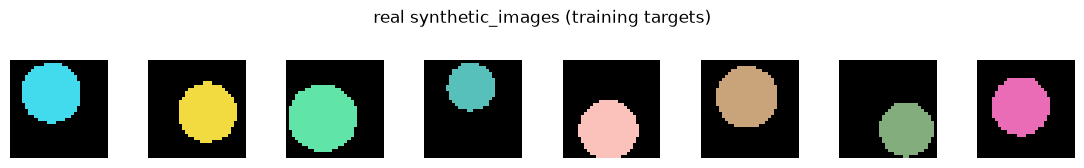

epoch 0  D 0.131  G 3.248


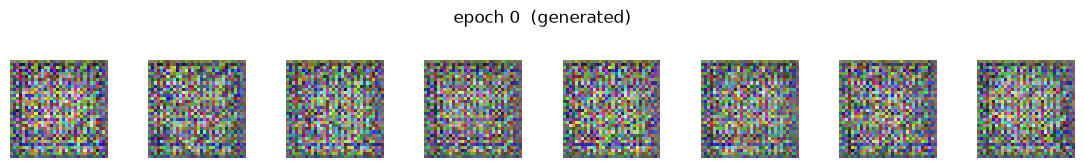

epoch 1  D 0.099  G 4.186


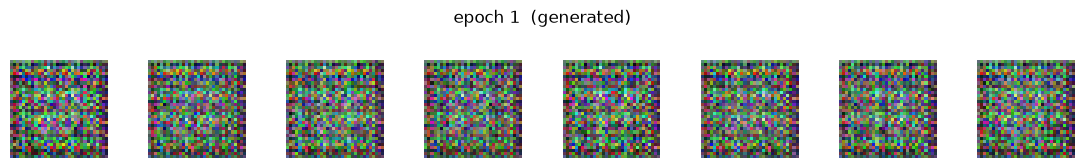

epoch 2  D 0.057  G 5.053


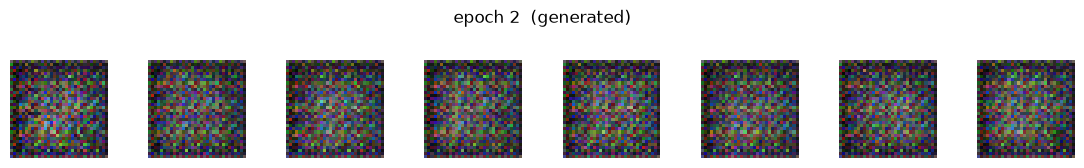

epoch 3  D 0.292  G 3.565


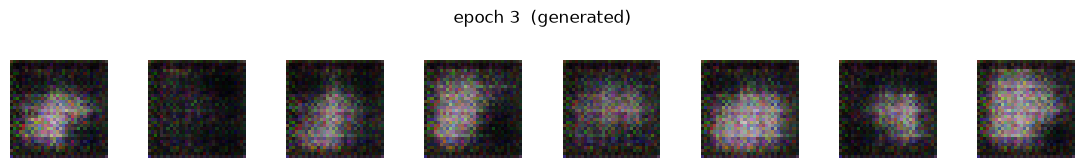

epoch 4  D 0.227  G 3.901


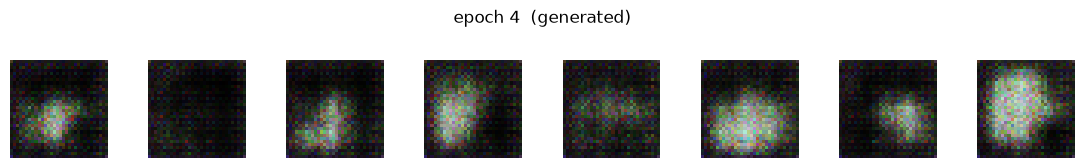

epoch 5  D 0.182  G 3.207


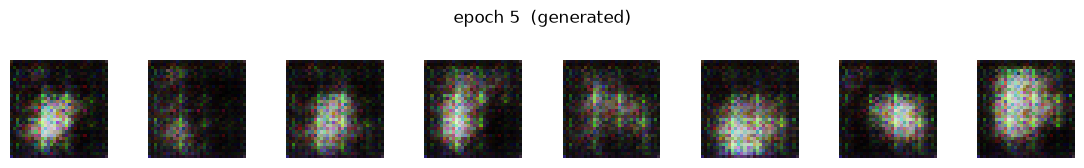

epoch 6  D 0.135  G 3.197


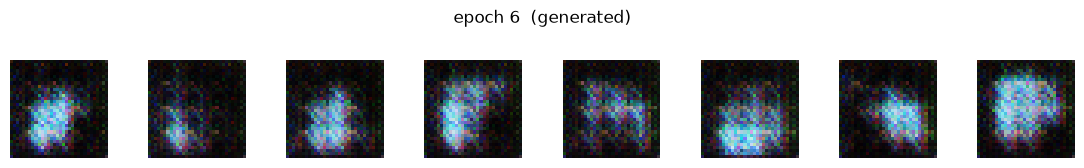

epoch 7  D 0.078  G 4.844


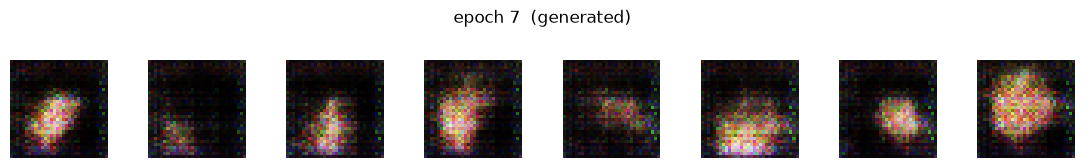

epoch 8  D 0.043  G 4.986


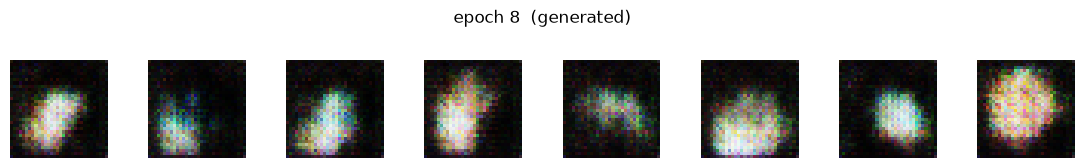

epoch 9  D 0.122  G 3.035


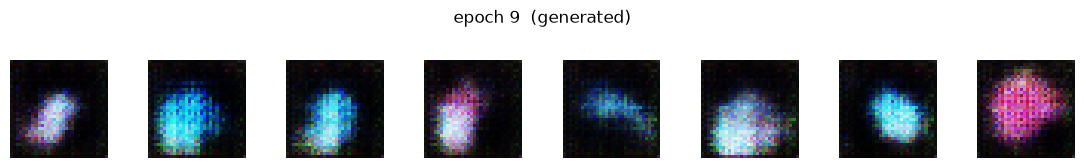

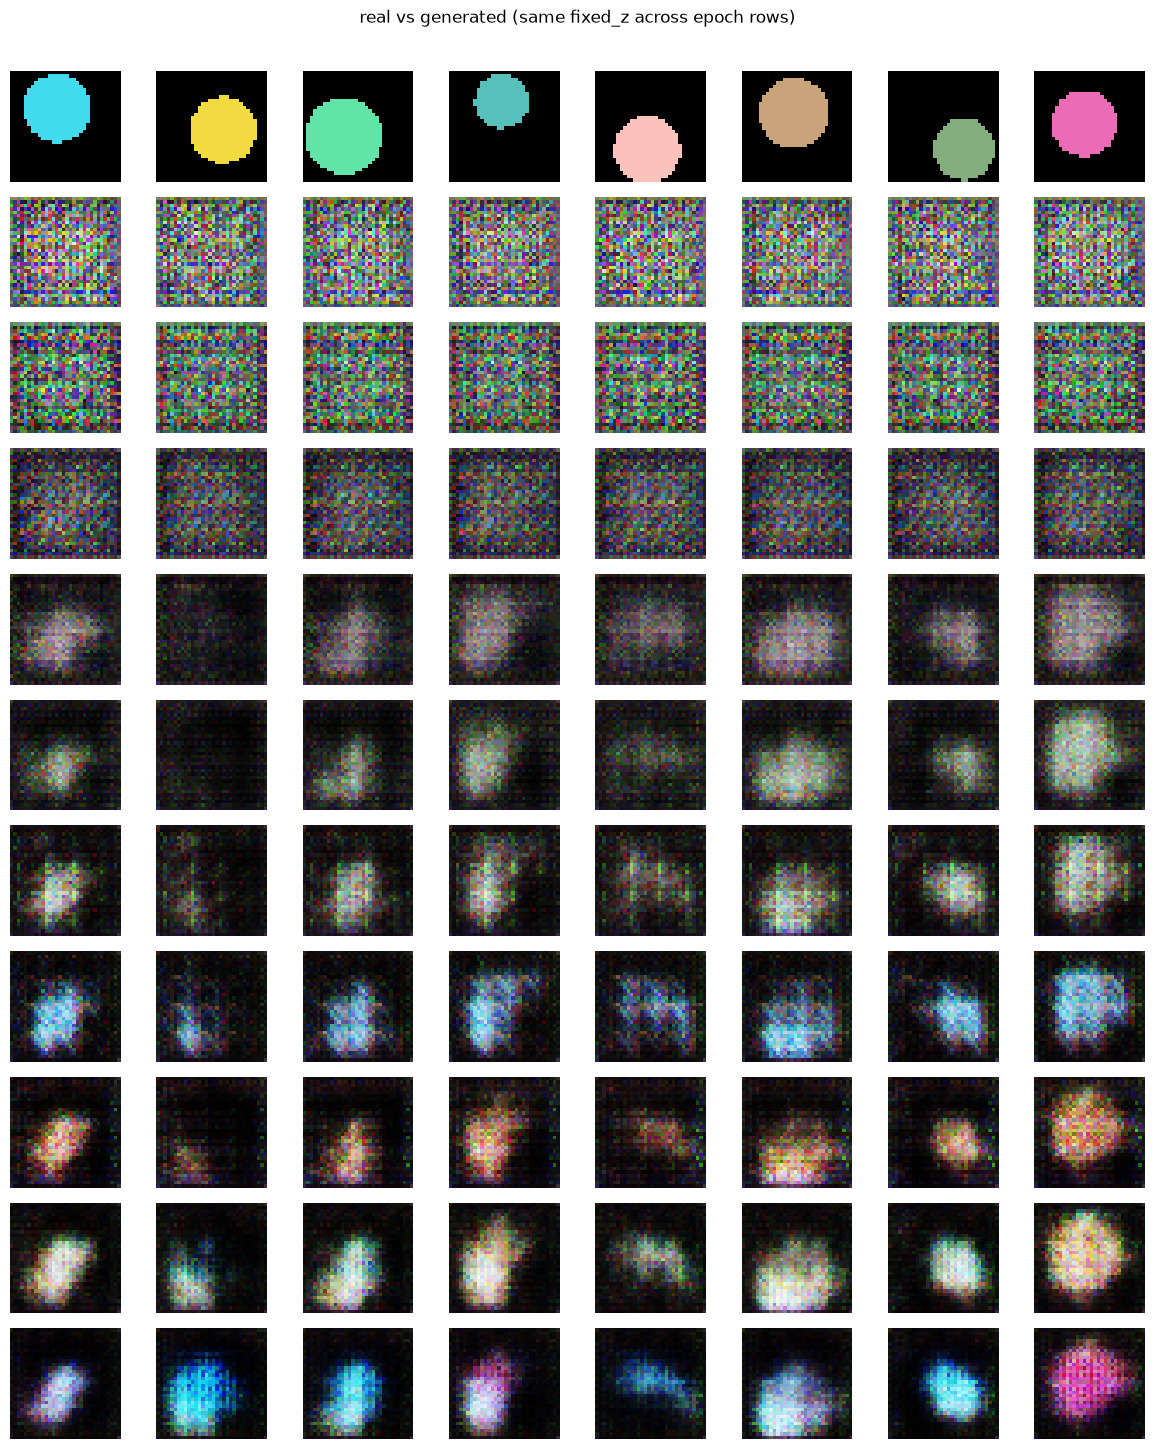

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

def synthetic_images(num=2000, size=32, seed=0):
    rng = np.random.default_rng(seed)
    imgs = np.zeros((num, 3, size, size), dtype=np.float32) - 1.0
    for i in range(num):
        r = rng.uniform(6, 12)
        cx, cy = rng.uniform(r, size - r, size=2)
        yy, xx = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 < r ** 2
        color = rng.uniform(-0.5, 1.0, size=3)
        for c in range(3):
            imgs[i, c][mask] = color[c]
    return torch.from_numpy(imgs)


def to_display(imgs):
    """Tanh output [-1, 1] -> numpy HWC in [0, 1]."""
    x = imgs.detach().cpu().clamp(-1, 1)
    x = (x + 1) * 0.5
    return x.permute(0, 2, 3, 1).numpy()


def show_image_row(imgs_nchw, title):
    imgs = to_display(imgs_nchw)
    n = imgs.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(1.4 * n, 1.6))
    if n == 1:
        axes = [axes]
    for ax, im in zip(axes, imgs):
        ax.imshow(im)
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
    return imgs


def show_epoch_samples(G, fixed_z, epoch):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_z)
    imgs = show_image_row(fake, f"epoch {epoch}  (generated)")
    G.train()
    return imgs


device = "mps" if torch.backends.mps.is_available() else "cpu"
data = synthetic_images()
loader = DataLoader(TensorDataset(data), batch_size=64, shuffle=True)

# real training samples for side-by-side comparison with G
real_preview = data[:8]
show_image_row(real_preview, "real synthetic_images (training targets)")

G = Generator(z_dim=64, img_channels=3, feat=32).to(device)
D = Discriminator(img_channels=3, feat=32).to(device)
opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# fixed noise so the same 8 slots are comparable across epochs
fixed_z = torch.randn(8, 64, device=device)
epoch_gallery = []

for epoch in range(20):
    for (batch,) in loader:
        z = torch.randn(batch.size(0), 64, device=device)
        ld, lg = train_step(G, D, batch, z, opt_g, opt_d, device)
    print(f"epoch {epoch}  D {ld:.3f}  G {lg:.3f}")
    epoch_gallery.append(show_epoch_samples(G, fixed_z, epoch))

# summary: first row = real data, then one row per epoch (fixed_z)
n_epochs = len(epoch_gallery)
fig, axes = plt.subplots(n_epochs + 1, 8, figsize=(12, 1.3 * (n_epochs + 1)))
real_imgs = to_display(real_preview)
for c in range(8):
    axes[0, c].imshow(real_imgs[c])
    axes[0, c].axis("off")
axes[0, 0].set_ylabel("real", rotation=0, labelpad=28, va="center")
for r, imgs in enumerate(epoch_gallery):
    for c in range(8):
        axes[r + 1, c].imshow(imgs[c])
        axes[r + 1, c].axis("off")
    axes[r + 1, 0].set_ylabel(f"ep{r}", rotation=0, labelpad=28, va="center")
fig.suptitle("real vs generated (same fixed_z across epoch rows)", y=1.01)
plt.tight_layout()
plt.show()